# Compare future monthly-climatology and annual FPC products, 2071–2100

This notebook calculates a calendar annual mean from `mfpc_pft_avg_2071_2100_monthly_mean.out` by averaging its 12 climatological monthly values at each grid cell. It then compares that result with `GFDL-ESM4_SSP585_fpc2071to2100.txt` field by field.

The signed difference is defined as

$$
\mathrm{difference}
=
\mathrm{mean\ of\ 12\ monthly\ climatological\ values}
-
\mathrm{supplied\ annual\ value}.
$$

The workflow checks monthly coverage, coordinate overlap, missing values, PFT columns, numerical differences, and their spatial patterns.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 12,
})

try:
    import cartopy.crs as ccrs
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

BASE_DIR = Path.home() / "BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS"
MONTHLY_FILE = BASE_DIR / "mfpc_pft_avg_2071_2100_monthly_mean.out"
PROVIDED_FILE = BASE_DIR / "GFDL-ESM4_SSP585_fpc2071to2100.txt"

START_YEAR, END_YEAR = 2071, 2100
EXPECTED_MONTHS = set(range(1, 13))
ROUNDING_TOLERANCE = 0.5e-3 + 1e-12
MAP_VARIABLES = ["Total", "Natural_sum", "Peatland_sum"]
SAVE_FIGURES = True
FIGURE_DIR = Path("06-original_vs_monthly_comparison_figures/GFDL-ESM4_SSP585_comparison")
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(exist_ok=True)

NATURAL_PFTS = [
    "BNE", "BINE", "BNS", "TeNE", "TeBE", "IBS", "TeBS", "C3G",
    "HSE", "HSS", "LSE", "LSS", "GRT", "EPDS", "SPDS", "CLM",
]
PEATLAND_PFTS = ["pLSE", "pLSS", "pCLM", "WetGRS", "pmoss", "C3G_wet", "C4G_wet"]
KEYS = ["Lon", "Lat"]

print(f"Monthly climatology: {MONTHLY_FILE}")
print(f"Annual reference:    {PROVIDED_FILE}")
print(f"Cartopy available:   {HAS_CARTOPY}")
assert MONTHLY_FILE.exists(), f"Monthly climatology not found: {MONTHLY_FILE}"
assert PROVIDED_FILE.exists(), f"Annual reference not found: {PROVIDED_FILE}"


Monthly climatology: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/mfpc_pft_avg_2071_2100_monthly_mean.out
Annual reference:    /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS/GFDL-ESM4_SSP585_fpc2071to2100.txt
Cartopy available:   True


## Data

### 1. Read the monthly climatology robustly

Repeated header rows are removed before numeric conversion. If the file unexpectedly contains a `Year` column, the code first restricts it to 2071–2100 and calculates the monthly climatology. Otherwise it treats the file as an already-computed 12-month climatology.


In [2]:
def read_monthly_climatology(path, start_year=2071, end_year=2100):
    raw = pd.read_csv(path, sep=r"\s+", dtype=str)
    if "Month" not in raw.columns:
        raise ValueError(f"Expected a Month column in {path}")

    month_numeric = pd.to_numeric(raw["Month"], errors="coerce")
    repeated_headers = int(month_numeric.isna().sum())
    raw = raw.loc[month_numeric.notna()].copy()
    raw["Month"] = month_numeric.loc[month_numeric.notna()].astype(int)

    numeric_columns = [column for column in raw.columns if column != "Year"]
    raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors="coerce")
    if raw[numeric_columns].isna().any().any():
        bad = raw.loc[raw[numeric_columns].isna().any(axis=1)].head()
        raise ValueError(f"Non-numeric or missing values found:\n{bad}")

    if "Year" in raw.columns:
        raw["Year"] = pd.to_numeric(raw["Year"], errors="coerce")
        raw = raw.loc[raw["Year"].between(start_year, end_year)].copy()
        value_columns = [column for column in raw.columns if column not in KEYS + ["Year", "Month"]]
        raw = raw.groupby(KEYS + ["Month"], as_index=False)[value_columns].mean()

    return raw, repeated_headers


monthly, repeated_headers_removed = read_monthly_climatology(
    MONTHLY_FILE, START_YEAR, END_YEAR
)
provided = pd.read_csv(PROVIDED_FILE, sep=r"\s+")

print(f"Repeated header rows removed: {repeated_headers_removed:,}")
print(f"Monthly rows: {len(monthly):,}")
print(f"Monthly coordinates: {monthly[KEYS].drop_duplicates().shape[0]:,}")
print(f"Annual-reference rows: {len(provided):,}")


Repeated header rows removed: 0
Monthly rows: 201,000
Monthly coordinates: 16,750
Annual-reference rows: 16,750


### 2. Validate coverage and calculate the temporal average

The temporal average is the unweighted arithmetic mean of the 12 climatological months. `Natural_sum` and `Peatland_sum` are reconstructed from their PFT columns when absent. `Total` is retained directly from the source file because its definition includes land-cover weighting.


In [3]:
assert not monthly.duplicated(KEYS + ["Month"]).any(), (
    "Duplicate coordinate-month rows remain after loading."
)
assert not provided.duplicated(KEYS).any(), "Duplicate coordinates in annual reference."
assert not monthly.isna().any().any(), "Missing values remain in monthly climatology."
assert not provided.isna().any().any(), "Missing values occur in annual reference."

month_sets = monthly.groupby(KEYS)["Month"].agg(lambda values: set(values))
incomplete_months = month_sets.loc[month_sets != EXPECTED_MONTHS]
assert incomplete_months.empty, (
    f"{len(incomplete_months)} coordinates do not contain all months 1–12."
)

missing_natural = set(NATURAL_PFTS).difference(monthly.columns)
missing_peatland = set(PEATLAND_PFTS).difference(monthly.columns)
assert not missing_natural, f"Missing natural PFT columns: {sorted(missing_natural)}"
assert not missing_peatland, f"Missing peatland PFT columns: {sorted(missing_peatland)}"

if "Natural_sum" not in monthly:
    monthly["Natural_sum"] = monthly[NATURAL_PFTS].sum(axis=1)
if "Peatland_sum" not in monthly:
    monthly["Peatland_sum"] = monthly[PEATLAND_PFTS].sum(axis=1)

provided_fields = [column for column in provided.columns if column not in KEYS]
missing_comparison_fields = set(provided_fields).difference(monthly.columns)
assert not missing_comparison_fields, (
    f"Monthly data cannot reproduce these reference fields: {sorted(missing_comparison_fields)}"
)

calculated = monthly.groupby(KEYS, as_index=False)[provided_fields].mean()

monthly_coords = pd.MultiIndex.from_frame(calculated[KEYS])
provided_coords = pd.MultiIndex.from_frame(provided[KEYS])
monthly_only_coords = monthly_coords.difference(provided_coords)
provided_only_coords = provided_coords.difference(monthly_coords)
common_coords = monthly_coords.intersection(provided_coords)

audit_parts = []
for coordinates, status in [
    (common_coords, "present in both"),
    (provided_only_coords, "annual file only"),
    (monthly_only_coords, "monthly file only"),
]:
    if len(coordinates):
        audit_parts.append(pd.DataFrame(coordinates.tolist(), columns=KEYS).assign(status=status))
coordinate_audit = pd.concat(audit_parts, ignore_index=True)
coordinate_audit.to_csv(FIGURE_DIR / "future_fpc_coordinate_coverage_audit.csv", index=False)

print(f"Coordinates with all 12 months: {len(monthly_coords):,}")
print(f"Coordinates present in both files: {len(common_coords):,}")
print(f"Annual-only coordinates: {len(provided_only_coords):,}")
print(f"Monthly-only coordinates: {len(monthly_only_coords):,}")
print("Coordinate audit saved to future_fpc_coordinate_coverage_audit.csv")


Coordinates with all 12 months: 16,750
Coordinates present in both files: 16,750
Annual-only coordinates: 0
Monthly-only coordinates: 0
Coordinate audit saved to future_fpc_coordinate_coverage_audit.csv


## Results

### 3. Compare every field

The table reports signed bias, mean absolute error (MAE), root-mean-square error (RMSE), maximum absolute difference, and the number of grid cells exceeding the ±0.0005 tolerance associated with three-decimal output.


In [4]:
# Mean and maximum across the 12 monthly climatology values
calculated = monthly.groupby(KEYS, as_index=False)[provided_fields].mean()
monthly_climatological_max = (
    monthly.groupby(KEYS, as_index=False)[provided_fields].max()
)

# Compare monthly-climatology mean with supplied annual values
comparison = calculated.merge(
    provided,
    on=KEYS,
    how="inner",
    suffixes=("_calculated", "_provided"),
    validate="one_to_one",
)

# Add monthly maximum values
comparison = comparison.merge(
    monthly_climatological_max.rename(
        columns={field: f"{field}_monthly_max" for field in provided_fields}
    ),
    on=KEYS,
    how="inner",
    validate="one_to_one",
)

summary_rows = []

for field in provided_fields:
    mean_difference = (
        comparison[f"{field}_calculated"]
        - comparison[f"{field}_provided"]
    )

    max_difference = (
        comparison[f"{field}_monthly_max"]
        - comparison[f"{field}_provided"]
    )

    comparison[f"{field}_mean_difference"] = mean_difference
    comparison[f"{field}_max_difference"] = max_difference

    summary_rows.append({
        "field": field,

        # Keep these names so your existing bar chart still works
        "mean difference": mean_difference.mean(),
        "mean absolute difference": mean_difference.abs().mean(),
        "RMSE": np.sqrt(np.mean(mean_difference**2)),
        "maximum absolute difference": mean_difference.abs().max(),

        # Maximum comparison
        "mean difference: monthly max": max_difference.mean(),
        "mean absolute difference: monthly max": max_difference.abs().mean(),
        "RMSE: monthly max": np.sqrt(np.mean(max_difference**2)),
        "maximum absolute difference: monthly max": max_difference.abs().max(),

        "cells compared": mean_difference.notna().sum(),
    })

summary = (
    pd.DataFrame(summary_rows)
    .set_index("field")
    .sort_values("mean absolute difference", ascending=False)
)

display(summary)

,mean difference,mean absolute difference,RMSE,maximum absolute difference,mean difference: monthly max,mean absolute difference: monthly max,RMSE: monthly max,maximum absolute difference: monthly max,cells compared
field,,,,,,,,,
Total,-2.609118e-01,2.609802e-01,0.305876,0.695221,-9.393957e-04,2.186395e-02,0.030797,0.237850,16750
Natural_sum,-2.467283e-01,2.469182e-01,0.298312,0.695223,-9.472995e-04,2.232158e-02,0.031070,0.237810,16750
Peatland_sum,-1.347120e-01,1.347120e-01,0.219760,0.709649,-2.051787e-04,1.603356e-02,0.038967,0.407767,16750
pmoss,-8.095317e-02,8.161065e-02,0.156321,0.467906,2.694645e-04,1.548339e-02,0.040683,0.486170,16750
BNS,-7.672133e-02,7.673753e-02,0.173317,0.652146,-6.755582e-05,1.055658e-02,0.028601,0.303270,16750
C3G,-6.147883e-02,6.153619e-02,0.093999,0.486521,-6.636966e-04,2.006089e-02,0.030387,0.258940,16750
WetGRS,-5.371607e-02,5.482246e-02,0.124788,0.590566,-4.490535e-04,1.895788e-02,0.054690,0.549360,16750
IBS,-5.265781e-02,5.271465e-02,0.091646,0.383888,-7.158166e-04,1.725604e-02,0.033149,0.213520,16750
GRT,-2.203057e-02,2.216959e-02,0.058266,0.375473,1.070034e-03,3.805213e-03,0.013049,0.204410,16750


### 4. Compare error magnitudes across fields

The bars show spatial MAE. The maximum absolute difference is overlaid as a point, distinguishing widespread disagreement from a small number of extreme cells.


KeyError: 'field'

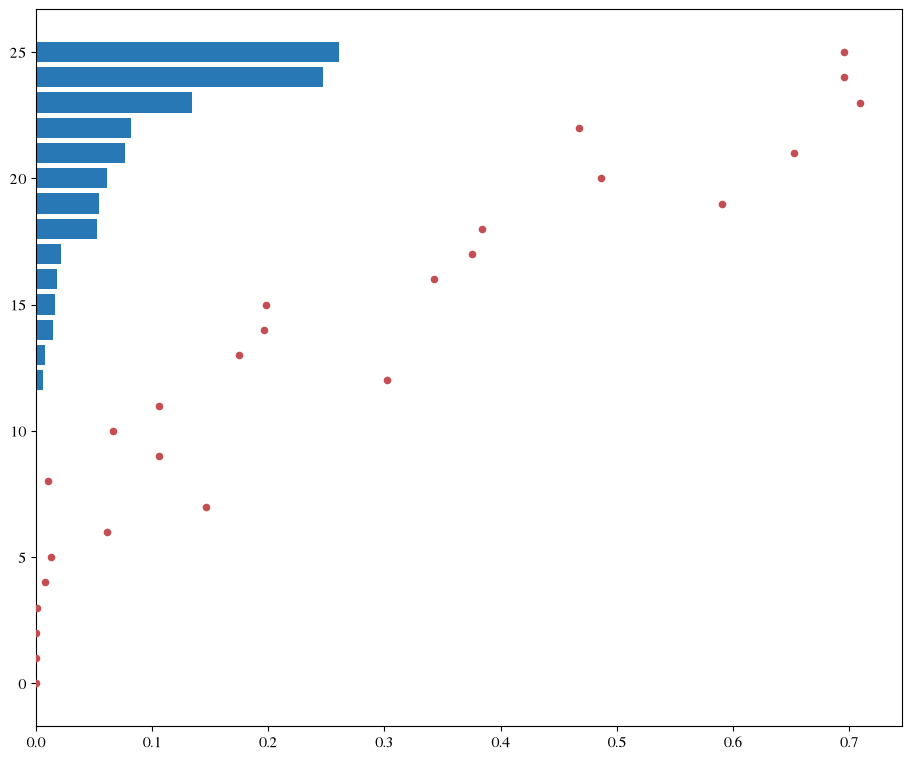

In [5]:
plot_summary = summary.sort_values("mean absolute difference")
y = np.arange(len(plot_summary))
fig, ax = plt.subplots(figsize=(9.0, 7.5), layout="constrained")
ax.barh(y, plot_summary["mean absolute difference"], color="#2878B5", label="MAE")
ax.scatter(plot_summary["maximum absolute difference"], y, color="#C44E52", s=20,
           label="Maximum absolute difference", zorder=3)
ax.set(yticks=y, yticklabels=plot_summary["field"],
       xlabel="Difference magnitude [FPC fraction]",
       title="Monthly-climatology annual mean versus supplied annual FPC")
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=False, loc="lower right")
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR / "difference_magnitude_by_field.png", dpi=200)
plt.show()


### 5. Map signed differences

The default maps show `Total`, `Natural_sum`, and `Peatland_sum`. Call `plot_difference_maps(["BNE", "BINE", "C3G"])` to inspect other fields. The colour range is clipped at the 99th percentile so that a few extreme cells do not obscure the dominant spatial pattern.


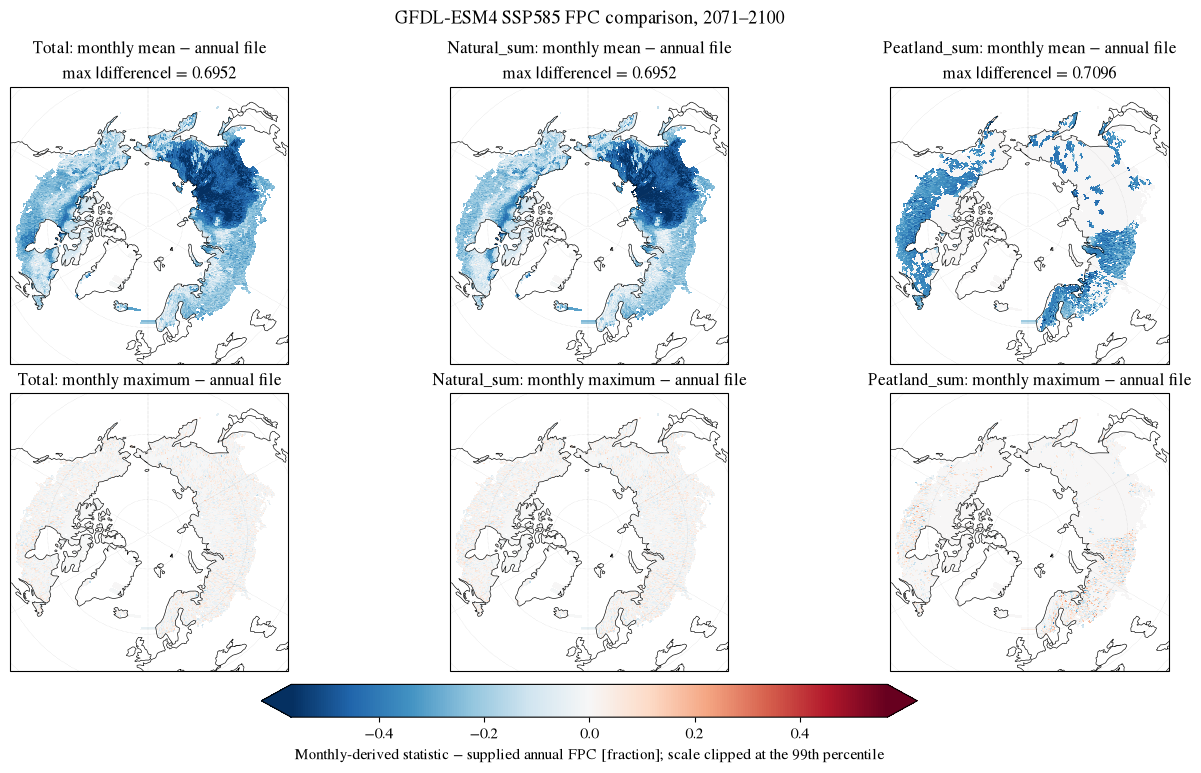

In [6]:
def difference_grid(field, statistic):
    suffixes = {
        "mean": "mean_difference",
        "max": "max_difference",
    }
    if statistic not in suffixes:
        raise ValueError("statistic must be 'mean' or 'max'")

    column = f"{field}_{suffixes[statistic]}"
    if column not in comparison:
        raise KeyError(
            f"Unknown field {field!r}; choose from {provided_fields}"
        )

    return (
        comparison
        .pivot(index="Lat", columns="Lon", values=column)
        .sort_index()
        .sort_index(axis=1)
    )


def draw_map(ax, grid, norm, title):
    if HAS_CARTOPY:
        image = ax.pcolormesh(
            grid.columns,
            grid.index,
            grid.to_numpy(),
            cmap="RdBu_r",
            norm=norm,
            shading="auto",
            transform=ccrs.PlateCarree(),
        )
        ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.45)
        ax.gridlines(
            linewidth=0.35,
            color="0.5",
            alpha=0.4,
            linestyle=":",
        )
    else:
        image = ax.pcolormesh(
            grid.columns,
            grid.index,
            grid.to_numpy(),
            cmap="RdBu_r",
            norm=norm,
            shading="auto",
            rasterized=True,
        )
        ax.set(
            xlim=(-180, 180),
            ylim=(45, 90),
            xlabel="Longitude",
            ylabel="Latitude",
        )
        ax.grid(alpha=0.2, linewidth=0.4)

    ax.set_title(title)
    return image


def plot_comparison_maps(
    fields=MAP_VARIABLES,
    filename="aggregate_mean_max_difference_maps.png",
    percentile=99,
    ncols=3,
):
    fields = list(fields)
    ncols = min(ncols, len(fields))
    rows_per_statistic = int(np.ceil(len(fields) / ncols))
    nrows = 2 * rows_per_statistic

    grids = {
        (field, statistic): difference_grid(field, statistic)
        for field in fields
        for statistic in ["mean", "max"]
    }

    finite_values = [
        grid.to_numpy()[np.isfinite(grid.to_numpy())]
        for grid in grids.values()
    ]
    values = np.concatenate(finite_values)

    vmax = max(
        float(np.percentile(np.abs(values), percentile)),
        1e-12,
    )
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    subplot_kw = (
        {"projection": ccrs.Orthographic(0, 90)}
        if HAS_CARTOPY
        else {}
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.4 * ncols, 3.8 * nrows),
        subplot_kw=subplot_kw,
        layout="constrained",
        squeeze=False,
    )

    for index, field in enumerate(fields):
        row = index // ncols
        column = index % ncols

        mean_grid = grids[(field, "mean")]
        max_grid = grids[(field, "max")]

        mean_max_abs = np.nanmax(np.abs(mean_grid.to_numpy()))
        max_max_abs = np.nanmax(np.abs(max_grid.to_numpy()))

        image = draw_map(
            axes[row, column],
            mean_grid,
            norm,
            (
                f"{field}: monthly mean − annual file\n"
                f"max |difference| = {mean_max_abs:.4f}"
            ),
        )

        draw_map(
            axes[row + rows_per_statistic, column],
            max_grid,
            norm,
            (
                f"{field}: monthly maximum − annual file"
                #f"\nmax |difference| = {max_max_abs:.4f}"
            ),
        )

    # Hide unused panels.
    for index in range(len(fields), rows_per_statistic * ncols):
        row = index // ncols
        column = index % ncols
        axes[row, column].set_visible(False)
        axes[row + rows_per_statistic, column].set_visible(False)

    colorbar = fig.colorbar(
        image,
        ax=axes,
        orientation="horizontal",
        shrink=0.5,
        pad=0.02,
        extend="both",
    )
    colorbar.set_label(
        "Monthly-derived statistic − supplied annual FPC "
        "[fraction]; scale clipped at the 99th percentile"
    )

    fig.suptitle(
        f"GFDL-ESM4 SSP585 FPC comparison, "
        f"{START_YEAR}–{END_YEAR}"
    )

    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, dpi=200)

    plt.show()


plot_comparison_maps()

### 6. Inspect individual PFTs

This example maps three strongly seasonal fields. Replace the list with any fields reported in the summary table.


In [ ]:
plot_comparison_maps(
    ['BNS', 'TeBS', 'SPDS', 'HSS', 'IBS', 'WetGRS', 'pmoss','GRT', 'C3G'], filename="example_difference_maps.png")


## Interpretation guide

- Differences within approximately ±0.0005 are consistent with a three-decimal representation of the same statistic.
- Widespread negative differences indicate that the 12-month calendar mean is systematically lower than the supplied annual product, as expected if the latter represents peak-season or another annual-state diagnostic.
- Spatially coherent differences should be interpreted as a mismatch in temporal definition before being attributed to numerical error.
- Historical and future anomalies should use the same temporal operator. Do not mix a calendar annual mean in one period with a peak-season or annual-state product in the other.
